#**In Silico Identification of Novel Compounds for Insomnia disease Step 4: QSAR MODEL**

##**Author: Maurizio Rafael Hernández Díaz. 2025-2026 Course**

The following step in our virtual screening workflow involves the development of a QSAR model, definied as a mathematical method to prodict propierties such as pysicochemical and biolgical from a compound based on its chemical structure. The following QSAR method aims to contruct an algorithm that is capable to predict the Inhibitory potency(pIC50) our desired target Orexin 2  receptor (OX2), the previously obtained database in `Step 1A: Retrival of the Orexin 2 recdptor(OX2) Antagonists from ChEMBL and ADME peopierties molecule filtering`.The optimized QSAR model will be applied to predict the activity of the Enamine GPCR library obtained in `Step 1B: Enamine  GPCRs library ADME propierties molecule filtering`

 Finally, the top-ranking candidates will advance in the workflow and will consequently  be evaluated thorugh a pharmacophore model.



##**0.-LIBRARIES REQUIRED:**

In [60]:
!pip install rdkit


In [61]:
#Importing required modules from the libraries:
import pandas as pd
import requests
from tqdm import tqdm 
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, MACCSkeys
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from rdkit.Chem import rdMolDescriptors
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import svm
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import cross_val_predict
from rdkit.Chem import Fragments
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from rdkit.Chem import Draw
import seaborn as sns
from rdkit.Chem import rdFingerprintGenerator

##**1.-Data Preparation**

We import as it was mentioned the contructed  ChEMBL database that will be used as Training and validation data and Enamine  GPCRs library that will be use as testing data as being the library we want to screen.

In [62]:
enamine_dataset = pd.read_csv("../DATA/Enamine_representative_set.csv")
chembl_dataset = pd.read_csv("../DATA/OX2_receptor_chembl_curated_database_definitive.csv")

Renaming the Dataset for easier understanding after its origin it was made clear as:

Screening_dataset -> enamine_dataset

Training_dataset -> chembl_dataset

In [63]:
Screening_dataset= enamine_dataset
Screening_dataset.drop(columns="Unnamed: 0")

,Unnamed: 0.1,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,QED,mol
0,0,O=C(NC1=NC(=NS1)C=2C=CC=CC2)C=3C(F)=CC=CC3Br,Z1343597788,378.220,378.220,3.017,-7.078,1,3,54.88,4,https://real.enamine.net/public-enum-files/Z13...,0.737020,<rdkit.Chem.rdchem.Mol object at 0x1429320a0>
1,1,CC1CC=2C=CC=CC2N1C(=O)C=3C=CN(N3)C=4C=CC(F)=CC4,Z391927422,321.349,321.349,3.646,-4.672,0,2,38.13,3,https://real.enamine.net/public-enum-files/Z39...,0.723111,<rdkit.Chem.rdchem.Mol object at 0x142931ee0>
2,2,CC=1C=CC(=CC1)C=2N=NN(CC(=O)NC=3C=CC=CC3OCC(F)...,Z241875964,391.348,391.348,3.408,-5.779,1,5,81.93,7,https://real.enamine.net/public-enum-files/Z24...,0.697764,<rdkit.Chem.rdchem.Mol object at 0x1429325e0>
3,3,FC=1C=CC=C(C1)NCC2=NC(=NO2)C3=CC=CO3,Z297575978,259.236,259.236,2.370,-3.198,1,3,64.09,4,https://real.enamine.net/public-enum-files/Z29...,0.779575,<rdkit.Chem.rdchem.Mol object at 0x142932650>
4,4,CC=1C=CC=CC1NC(=O)C2CCCN2C3=NC=CS3,Z391936202,287.382,287.382,2.052,-3.989,1,3,45.23,3,https://real.enamine.net/public-enum-files/Z39...,0.943378,<rdkit.Chem.rdchem.Mol object at 0x1429326c0>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7702,45103,CC(NC1=NC=2C=CC=CC2S1)C=3C=C(F)C=CC3N4CCC(O)CC4,Z1148790310,371.474,371.474,3.448,-5.330,2,4,48.39,4,https://real.enamine.net/public-enum-files/Z11...,0.705300,<rdkit.Chem.rdchem.Mol object at 0x34ad10430>
7703,45105,C1=CC=2CN(CC3=NN=NN3CC=4C=CC=CC4)CCC2S1,Z225167016,311.407,311.407,2.794,-2.490,0,4,46.84,4,https://real.enamine.net/public-enum-files/Z22...,0.741836,<rdkit.Chem.rdchem.Mol object at 0x34ad10510>
7704,45114,CN1C(=NC=2C=CC=CC21)NCC(C=3C=CC=CC3Cl)N4CCOCC4,Z1454327087,370.876,370.876,4.483,-4.083,1,4,42.32,5,https://real.enamine.net/public-enum-files/Z14...,0.743019,<rdkit.Chem.rdchem.Mol object at 0x34ad10900>
7705,45115,CCN1C(CN2N=CSC2=O)=NC=3C(F)=CC=CC31,Z1822510276,278.307,278.307,2.708,-2.728,0,3,50.49,3,https://real.enamine.net/public-enum-files/Z18...,0.734553,<rdkit.Chem.rdchem.Mol object at 0x34ad10970>


Same for the training and validation data:

In [64]:
Training_data=chembl_dataset
Training_data.drop(columns="Unnamed: 0")
#We will storage only the pIC50 as previously explained : I will be working with pIC50 values as it aligns with biological systems’ logarithmic response, and simplifies potency comparisons across compounds, aiding in clearer data interpretation.
Training_data= Training_data[["molecule_chembl_id",
                              "canonical_smiles",
                              "pIC50",
                              ]]
Training_data

,molecule_chembl_id,canonical_smiles,pIC50
0,CHEMBL142009,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccncc1)C(C)(...,7.397940
1,CHEMBL343786,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccsc1)C(C)(C...,7.455932
2,CHEMBL139634,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccnc1)C(C)(...,6.619789
3,CHEMBL140547,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccn1C)C(C)(...,7.552842
4,CHEMBL344622,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccs1)C(C)(C...,7.602060
...,...,...,...
682,CHEMBL5905339,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,8.080922
683,CHEMBL5760626,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.966576
684,CHEMBL5998404,COC(=O)N1[C@H](C)C[C@H](NS(C)(=O)=O)[C@@H]1CO[...,7.593460
685,CHEMBL5752182,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.728158


Lets check if they are any missing values or duplicated rows:


In [65]:
Training_data.dropna().reset_index(drop=True)
Training_data.drop_duplicates().reset_index(drop=True)

,molecule_chembl_id,canonical_smiles,pIC50
0,CHEMBL142009,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccncc1)C(C)(...,7.397940
1,CHEMBL343786,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccsc1)C(C)(C...,7.455932
2,CHEMBL139634,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccnc1)C(C)(...,6.619789
3,CHEMBL140547,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccn1C)C(C)(...,7.552842
4,CHEMBL344622,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccs1)C(C)(C...,7.602060
...,...,...,...
682,CHEMBL5905339,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,8.080922
683,CHEMBL5760626,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.966576
684,CHEMBL5998404,COC(=O)N1[C@H](C)C[C@H](NS(C)(=O)=O)[C@@H]1CO[...,7.593460
685,CHEMBL5752182,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.728158


In [66]:
print(f"Duplicates after dropping them: {Training_data.duplicated().sum()}")

Duplicates after dropping them: 0


In [67]:
#We transform the pIC50	 into numbers just in case
Training_data['pIC50'] = pd.to_numeric(Training_data['pIC50'], errors='coerce')

In [68]:
Training_data


,molecule_chembl_id,canonical_smiles,pIC50
0,CHEMBL142009,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccncc1)C(C)(...,7.397940
1,CHEMBL343786,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1ccsc1)C(C)(C...,7.455932
2,CHEMBL139634,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccnc1)C(C)(...,6.619789
3,CHEMBL140547,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccn1C)C(C)(...,7.552842
4,CHEMBL344622,COc1cc2c(cc1OC)CN(C(=O)[C@@H](NCc1cccs1)C(C)(C...,7.602060
...,...,...,...
682,CHEMBL5905339,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,8.080922
683,CHEMBL5760626,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.966576
684,CHEMBL5998404,COC(=O)N1[C@H](C)C[C@H](NS(C)(=O)=O)[C@@H]1CO[...,7.593460
685,CHEMBL5752182,COC(=O)N1[C@H](C)C[C@H](NS(=O)(=O)N(C)C)[C@@H]...,6.728158


In [69]:
Training_data_QSAR =Training_data.copy()
Training_data_QSAR=Training_data_QSAR.rename(columns={"mol":"Mol"})

In [70]:
Training_data_QSAR["Mol"] = Training_data_QSAR["canonical_smiles"].apply(Chem.MolFromSmiles)

###**2.-Descriptors Selection**:

Once I have a clean and ready to go dataset, we can calculate the descriptors, general descriptors used for QSAR obtained from the class notebooks were used, combined with other descriptors which are specific to the Orexine  inhibitors and the desired effects of reducing sleep latency and improving sleep maintenance some of this characteristics descriptors for the target of study are:

A)Certain characteristics of the targeted receptor must be mention as it is part of the nervous system it is needed that the molecules can go thourgh the blood-brain barrier. In relation to this we can use topological indexes that informs us that the best Kappa-scored molecules tend to pass the blood-brain barrer.

B) Most orexine 2 receptor antagonist always present an amide central group or a piperidine subsuituted ring

C)Regarding 3D descriptors some of them were used, NPR1 & NPR2 (Normalized Principal Moments of Inertia) as these descriptors meassure the three dimensional shape of the molecule as most Orexine 2 receptor approved drugs present a folded "U" shape.

D) HallKierAlpha: Measures atomic shape and hybridization. It is excellent for predicting GPCR binding.

E)MaxRender or SlogP_VSA: A surface area (VSA) descriptor from RDKit helps to understand how lipophilicity is distributed in 3D.

F)NumAromaticHeterocycles: Orexins rely heavily on rings such as pyrimidines or triazoles.



In [71]:
#Lipophilicity descriptors
Training_data_QSAR["LogP"] = Training_data_QSAR["Mol"].apply(Descriptors.MolLogP) #LogP as lypholic behaviour associated with absortion, really important regarding blood-brain barrier absorption


#Charge descriptors
Training_data_QSAR["MaxAbsPartial"] = Training_data_QSAR["Mol"].apply(Descriptors.MaxAbsPartialCharge)
Training_data_QSAR["MaxPartialCharge"] =  Training_data_QSAR["Mol"].apply(Descriptors.MaxPartialCharge)
Training_data_QSAR["MinAbsPartial"]= Training_data_QSAR["Mol"].apply(Descriptors.MinAbsPartialCharge)
Training_data_QSAR["MinPartialCharge"] =  Training_data_QSAR["Mol"].apply(Descriptors.MinPartialCharge)

#Size and shape descriptors.
Training_data_QSAR["TPSA"] = Training_data_QSAR["Mol"].apply(Descriptors.TPSA) #Topological surface area, defined  polar surface area of a molecule based on its 2D structure, also ensential in blood-brain barrier absorption
Training_data_QSAR["MW"] = Training_data_QSAR["Mol"].apply(Descriptors.MolWt) #Molecular weight

Training_data_QSAR["SlogP_VSA2"] = Training_data_QSAR["Mol"].apply(lambda x: Descriptors.SlogP_VSA2(x))
Training_data_QSAR["SMR_VSA1"] = Training_data_QSAR["Mol"].apply(lambda x: Descriptors.SMR_VSA1(x))

# PBF measures the deviation from planarity; 3D-shaped molecules often show better CNS selectivity.
Training_data_QSAR["NumAliphaticRings"] = Training_data_QSAR["Mol"].apply(Lipinski.NumAliphaticRings)

#Aromacitty and rings.
Training_data_QSAR["AromaticRings"] =Training_data_QSAR["Mol"].apply(Lipinski.NumAromaticRings) #Really important regarding H1 receptor as the typical drugs usually present two aromatic rings
Training_data_QSAR["RingCount"] = Training_data_QSAR["Mol"].apply(Descriptors.RingCount)
Training_data_QSAR["NumHAcceptors"] = Training_data_QSAR["Mol"].apply(Chem.Lipinski.NumHAcceptors)
Training_data_QSAR["NumHDonors"] = Training_data_QSAR["Mol"].apply(Chem.Lipinski.NumHDonors)
#Flexibility and shape
Training_data_QSAR["RotatableBonds"] =Training_data_QSAR["Mol"].apply(Lipinski.NumRotatableBonds) #Molecular flexibility, really important considering the induce fit approach Im taking

#Targeted descriptors
Training_data_QSAR["Kappa1"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcKappa1)
Training_data_QSAR["Kappa2"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcKappa2)
Training_data_QSAR["Fsp3"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcFractionCSP3)
Training_data_QSAR["NumAmideBonds"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcNumAmideBonds)
Training_data_QSAR["HallKierAlpha"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcHallKierAlpha)
Training_data_QSAR["NumAromaticHeterocycles"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcNumAromaticHeterocycles)
Training_data_QSAR["NumChlorine"] = Training_data_QSAR["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[Cl]"))))
Training_data_QSAR["HeavyAtomCount"] = Training_data_QSAR["Mol"].apply(Descriptors.HeavyAtomCount)
Training_data_QSAR["NumFluorine"] = Training_data_QSAR["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[F]"))))
Training_data_QSAR["NumNitrogen"] = Training_data_QSAR["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[N]"))))
Training_data_QSAR["LabuteASA"] = Training_data_QSAR["Mol"].apply(rdMolDescriptors.CalcLabuteASA)


Regarding 3D descriptors some of them were used, NPR1 & NPR2 (Normalized Principal Moments of Inertia) as these descriptors meassure the three dimensional shape of the molecule as most sedant antihistamines present certain three dinmensional characteristics such as a "disc-like" producing NPR1 values amoung others


In [72]:


def get_3d_descriptors(mol):
    """
    Calculate 3D descriptroes for the QSAR model
    """
    if mol is None:
        return [None] * 6

    try:

        m3d = Chem.AddHs(mol)


        params = AllChem.ETKDGv3()
        params.randomSeed = 42

        if AllChem.EmbedMolecule(m3d, params) == -1:

            if AllChem.EmbedMolecule(m3d, randomSeed=42, useRandomCoords=True) == -1:
                return [None] * 6


        try:
            AllChem.MMFFOptimizeMolecule(m3d)
        except:
            pass

        pbf  = rdMolDescriptors.CalcPBF(m3d)
        npr1 = rdMolDescriptors.CalcNPR1(m3d)
        npr2 = rdMolDescriptors.CalcNPR2(m3d)
        rg   = rdMolDescriptors.CalcRadiusOfGyration(m3d)
        asph = rdMolDescriptors.CalcAsphericity(m3d)
        ecc  = rdMolDescriptors.CalcEccentricity(m3d)

        return [pbf, npr1, npr2, rg, asph, ecc]

    except Exception:
        return [None] * 6


threed_cols = ["PBF", "NPR1", "NPR2", "RadiusOfGyration", "Asphericity", "Eccentricity"]


descriptors_3d_list = Training_data_QSAR["Mol"].apply(get_3d_descriptors).tolist()


Training_data_QSAR[threed_cols] = pd.DataFrame(descriptors_3d_list, index=Training_data_QSAR.index)


Training_data_QSAR = Training_data_QSAR.dropna(subset=threed_cols)


In [73]:
Training_data_QSAR.columns
descriptors_colums=['LogP',
       'MaxAbsPartial', 'MaxPartialCharge', 'MinAbsPartial',
       'MinPartialCharge', 'TPSA', 'MW', 'SlogP_VSA2', 'SMR_VSA1',
       'NumAliphaticRings', 'AromaticRings', 'RingCount', 'NumHAcceptors',
       'NumHDonors', 'RotatableBonds', 'Kappa1', 'Kappa2', 'Fsp3',
       'NumAmideBonds', 'HallKierAlpha', 'NumAromaticHeterocycles',
       'NumChlorine', 'HeavyAtomCount', 'NumFluorine', 'NumNitrogen',
       'LabuteASA', 'PBF', 'NPR1', 'NPR2', 'RadiusOfGyration', 'Asphericity',
       'Eccentricity']

Local atomic environments and important molecular substructures are encoded by Morgan fingerprints (ECFP4, radius = 2). They are ideal for QSAR modeling because they effectively capture functional groups, aromatic and heterocyclic patterns, and structural characteristics important for ligand-receptor interactions.

In [74]:

def get_morgan_fp_new(mol):
    if mol is None: return np.zeros(1024)



    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


    fp = gen.GetFingerprintAsNumPy(mol)
    return fp

fps = np.stack(Training_data_QSAR["Mol"].apply(get_morgan_fp_new))


df_fps = pd.DataFrame(fps, columns=[f"Bit_{i}" for i in range(1024)], index=Training_data_QSAR.index)

Training_data_QSAR = pd.concat([Training_data_QSAR, df_fps], axis=1)


all_descriptors = descriptors_colums + [f"Bit_{i}" for i in range(1024)]



In [75]:
all_descriptors = descriptors_colums + [f"Bit_{i}" for i in range(1024)]

###**3.-ALGORITHMS TESTED**:

###**3.1-Regression methods**:

####**3.1.1-RANDOM FOREST**

The first algorithm I tested is Random Forest for many reasons: It is a robus method that handles noisy data in a excellent way as random forest are able to capture non-linear relationships between the variables and no steps such as scaling or intense preprocessing are required appart from that previous QSAR obtained really good metrics using this algorithm.

In [76]:
#Define variables
rf = Training_data_QSAR.copy()

# X: Descriptors only
X = rf[all_descriptors]

# Target variable
Y = rf["pIC50"]

# Check shapes
print(X.shape, Y.shape)

(687, 1056) (687,)


We divide into training and test set:

In [77]:
# Split the dataset into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2, random_state=42)


Once I splitted the data into training and test set, I will test several algorithms in order to compare their performance to predict the Inhibitory potency(pIC50) our desired target H1 histamine receptor.

In [78]:

rf = RandomForestRegressor(
    n_estimators=800,
    max_features='sqrt',
    max_depth=20,
    min_samples_leaf=2,
    random_state=42
)
param_distributions = {
    'n_estimators': [100, 200,300],
    'max_depth': [10,20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['log2', 'sqrt'],
    'bootstrap': [True, False]}

**It is important to mentio nwe cant dependend in only one train and test so we complete a cross-validation**


In [79]:
#Train the model with crossvalidation to avoid overfitting
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#Then we do the hyperparameter tuning to find the best parameters for our model
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=45,
    cv=cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1, verbose=1)


random_search.fit(X_train, Y_train)
print(random_search.best_params_)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}


In [80]:
best_model_rf = random_search.best_estimator_
Y_pred = best_model_rf.predict(X_test)
Y_pred

array([7.65136024, 7.44451813, 7.05227473, 7.50673172, 7.80528729,
       7.09411232, 7.40194131, 7.12321473, 7.63153038, 7.12488969,
       7.44191066, 7.1971821 , 7.41204644, 7.74477348, 8.3969789 ,
       7.12786761, 7.36836506, 7.64359068, 7.22078967, 7.5649444 ,
       7.26957829, 7.60924585, 7.71759779, 7.37297614, 7.80421258,
       7.61061899, 7.18468089, 7.44269743, 7.52278163, 7.54041796,
       7.35085209, 7.10641623, 7.17832524, 8.11990465, 7.00486369,
       7.10602901, 7.0424664 , 7.43496212, 7.26537599, 7.26431825,
       7.26990926, 7.7613984 , 7.35564876, 7.23739698, 7.72125648,
       7.64390122, 7.66358852, 7.38116158, 7.77733259, 7.3510304 ,
       8.79185968, 7.57479835, 7.43931787, 7.36062232, 6.86712917,
       7.58258624, 7.12944659, 7.4164138 , 7.06745263, 7.22579473,
       6.94753313, 7.26259524, 7.65228751, 7.7762808 , 7.19630289,
       7.72174069, 7.05715754, 7.67973225, 7.97229694, 7.43186549,
       7.32643673, 7.31240078, 7.39772658, 7.60254835, 7.35894

In [81]:
mae_rf = mean_absolute_error(Y_test, Y_pred)
mse_rf = mean_squared_error(Y_test, Y_pred)
rmse_rf = root_mean_squared_error(Y_test, Y_pred)
r2_rf = r2_score(Y_test, Y_pred)
print(f"The R² using  Random Forest algorithm is : {r2_rf}")
print(f"The Mean absolute error using Random Forest algorithm is : {mae_rf}")

The R² using  Random Forest algorithm is : 0.3258342007762649
The Mean absolute error using Random Forest algorithm is : 0.3472330476838241


##**3.1.2.-.GRADIENT BOOST**

Gradient Boosting is an ensemble machine learning technique that builds a series of decision trees, each aimed at correcting the errors of the previous ones.

As explained by  the sklearn documentation: "This estimator builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage a regression tree is fit on the negative gradient of the given loss function."


In [82]:
y = Training_data_QSAR["pIC50"].values
X = Training_data_QSAR[descriptors_colums].values
# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model
gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

#We train the model
gbr.fit(X_train, y_train)

# We establish the predictions
y_pred = gbr.predict(X_test)

# Final results of the model
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f" The R² using Gradient boost algorithm is  : {r2:.3f}")
print(f"The Mean absolute error using Gradient boost algorithm is : {mae}")

 The R² using Gradient boost algorithm is  : 0.060
The Mean absolute error using Gradient boost algorithm is : 0.41884688150139987


##**3.1.3.-.Support vector machines**

In [83]:
X= Training_data_QSAR[descriptors_colums]
y= Training_data_QSAR["pIC50"]
X = X.astype(float)
y = y.astype(float)

**The SVR needs of an scaling step, I use StandarScaler as used before for other courses(E.g Machine Learning)**

In [84]:
preprocessor = ColumnTransformer(
    [("scaler", StandardScaler(), X.columns)],
    remainder="passthrough"
)


svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])



We train the model:

In [85]:
svr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0


In [86]:
preds = svr_model.predict(X)

/Users/maurizioh/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [87]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"The R² using support vector machine is: {r2:.4f}")
print(f"The Mean absolute error using support vector machine is: {mae:.4f}")

The R² using support vector machine is: 0.0599
The Mean absolute error using support vector machine is: 0.4188


An overview of all the obtained results:


In [88]:

print(f" The R² using Gradient boost algorithm is  : {r2:.3f}")
print(f"The Mean absolute error using Gradient boost algorithm is : {mae}")

print(f"The R² using  Random Forest algorithm is : {r2_rf}")
print(f"The Mean absolute error using Random Forest algorithm is : {mae_rf}")


print(f"The R² using support vector machine is: {r2:.4f}")
print(f"The Mean absolute error using support vector machine is: {mae:.4f}")


 The R² using Gradient boost algorithm is  : 0.060
The Mean absolute error using Gradient boost algorithm is : 0.41884688150139987
The R² using  Random Forest algorithm is : 0.3258342007762649
The Mean absolute error using Random Forest algorithm is : 0.3472330476838241
The R² using support vector machine is: 0.0599
The Mean absolute error using support vector machine is: 0.4188


 As an overview of the metrics for the regression models:

Coefficient of Determination (R²): Measures how
well the predictions fit the actual data. Values close to 1 indicate a strong fit.
• Mean Absolute Error (MAE): The average absolute
difference between predicted and actual values.

We can see that we have a relatively good  R^2 and the MAE, which measures the difference between predicted and actual values, is also good. However, we can further refine the model through feature selection.

Based on this the best regression model that will be used as a first layer to be applied to the Enamine  GPCRs library is **Random Forest regression**

This way we can say we can implement a Logistic Regresion clasiciator

Overview: A regression algorirhm was built in order to predict inhibitory activity to the OX1 (the best method obtain was Random forest). Controls will be evaluated.

This regression and classification algorithm will be applied to the choosen GCPR library in order to obtain the best ranked inhibitors from the screening library.

##**4.-CONTROLS EVALUATION OF THE MODELS**

##**5.-QSAR BASED SCREENING ON THE GCPR ENIAM LIBRARY**

In [89]:
enamine_dataset.drop(columns="Unnamed: 0")
enamine_dataset["Mol"] = enamine_dataset["SMILES"].apply(Chem.MolFromSmiles)
df=enamine_dataset.copy()

In [90]:
#Lipophilicity descriptors
df["LogP"] = df["Mol"].apply(Descriptors.MolLogP) #LogP as lypholic behaviour associated with absortion, really important regarding blood-brain barrier absorption


#Charge descriptors
df["MaxAbsPartial"] = df["Mol"].apply(Descriptors.MaxAbsPartialCharge)
df["MaxPartialCharge"] =  df["Mol"].apply(Descriptors.MaxPartialCharge)
df["MinAbsPartial"]= df["Mol"].apply(Descriptors.MinAbsPartialCharge)
df["MinPartialCharge"] =  df["Mol"].apply(Descriptors.MinPartialCharge)

#Size and shape descriptors.
df["TPSA"] = df["Mol"].apply(Descriptors.TPSA) #Topological surface area, defined  polar surface area of a molecule based on its 2D structure, also ensential in blood-brain barrier absorption
df["MW"] = df["Mol"].apply(Descriptors.MolWt) #Molecular weight

df["SlogP_VSA2"] = df["Mol"].apply(lambda x: Descriptors.SlogP_VSA2(x))
df["SMR_VSA1"] = df["Mol"].apply(lambda x: Descriptors.SMR_VSA1(x))

# PBF measures the deviation from planarity; 3D-shaped molecules often show better CNS selectivity.
df["NumAliphaticRings"] = df["Mol"].apply(Lipinski.NumAliphaticRings)

#Aromacitty and rings.
df["AromaticRings"] = df["Mol"].apply(Lipinski.NumAromaticRings) #Really important regarding H1 receptor as the typical drugs usually present two aromatic rings
df["RingCount"] = df["Mol"].apply(Descriptors.RingCount)
df["NumHAcceptors"] = df["Mol"].apply(Chem.Lipinski.NumHAcceptors)
df["NumHDonors"] = df["Mol"].apply(Chem.Lipinski.NumHDonors)
#Flexibility and shape
df["RotatableBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds) #Molecular flexibility, really important considering the induce fit approach Im taking

#Targeted descriptors
df["Kappa1"] = df["Mol"].apply(rdMolDescriptors.CalcKappa1)
df["Kappa2"] = df["Mol"].apply(rdMolDescriptors.CalcKappa2)
df["Fsp3"] = df["Mol"].apply(rdMolDescriptors.CalcFractionCSP3)
df["NumAmideBonds"] = df["Mol"].apply(rdMolDescriptors.CalcNumAmideBonds)
df["HallKierAlpha"] = df["Mol"].apply(rdMolDescriptors.CalcHallKierAlpha)
df["NumAromaticHeterocycles"] = df["Mol"].apply(rdMolDescriptors.CalcNumAromaticHeterocycles)
df["NumChlorine"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[Cl]"))))
df["HeavyAtomCount"] = df["Mol"].apply(Descriptors.HeavyAtomCount)


df["NumFluorine"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[F]"))))
df["NumNitrogen"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[N]"))))

df["LabuteASA"] = df["Mol"].apply(rdMolDescriptors.CalcLabuteASA)


In [91]:
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
import pandas as pd
from tqdm import tqdm

def get_3d_descriptors(mol):
    if mol is None:
        return [None] * 6

    try:
        m3d = Chem.AddHs(mol)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42

        if AllChem.EmbedMolecule(m3d, params) == -1:
            if AllChem.EmbedMolecule(m3d, randomSeed=42, useRandomCoords=True) == -1:
                return [None] * 6

        try:
            AllChem.MMFFOptimizeMolecule(m3d)
        except:
            pass

        pbf  = rdMolDescriptors.CalcPBF(m3d)
        npr1 = rdMolDescriptors.CalcNPR1(m3d)
        npr2 = rdMolDescriptors.CalcNPR2(m3d)
        rg   = rdMolDescriptors.CalcRadiusOfGyration(m3d)
        asph = rdMolDescriptors.CalcAsphericity(m3d)
        ecc  = rdMolDescriptors.CalcEccentricity(m3d)

        return [pbf, npr1, npr2, rg, asph, ecc]
    except Exception:
        return [None] * 6

threed_cols = ["PBF", "NPR1", "NPR2", "RadiusOfGyration", "Asphericity", "Eccentricity"]

tqdm.pandas(desc="Calculating 3D descriptors")
descriptors_3d_list = df["Mol"].progress_apply(get_3d_descriptors).tolist()

df[threed_cols] = pd.DataFrame(descriptors_3d_list, index=df.index)
df = df.dropna(subset=threed_cols)

Calculating 3D descriptors: 100%|██████████| 7707/7707 [20:09<00:00,  6.37it/s]   


In [92]:

def get_morgan_fp_new(mol):
    if mol is None: return np.zeros(1024)


    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


    fp = gen.GetFingerprintAsNumPy(mol)
    return fp



fps = np.stack(df["Mol"].apply(get_morgan_fp_new))


df_fps = pd.DataFrame(fps, columns=[f"Bit_{i}" for i in range(1024)], index=df.index)


df = pd.concat([df, df_fps], axis=1)


all_descriptors = descriptors_colums + [f"Bit_{i}" for i in range(1024)]



In [93]:
df = df.loc[:, ~df.columns.duplicated(keep='first')]

all_descriptors = list(dict.fromkeys(all_descriptors))


model_features = best_model_rf.feature_names_in_


X_enamine_final = df[all_descriptors].reindex(columns=model_features)


In [94]:
X_enamine_final = X_enamine_final.fillna(0)

In [95]:
df['predicted_pIC50'] = best_model_rf.predict(X_enamine_final)

enamine_results = df.sort_values(by='predicted_pIC50', ascending=False)

print(enamine_results[['Catalog ID', 'predicted_pIC50']].head(10))

       Catalog ID  predicted_pIC50
4200  Z1299743830         7.849245
4420  Z1423689861         7.789506
1136    Z94530561         7.661401
782   Z2442926991         7.656428
241     Z52144468         7.635757
378     Z95663208         7.634004
1814  Z3409607914         7.618767
3688  Z1615189436         7.608491
2064   Z135159634         7.607931
1387  Z2299580102         7.593243


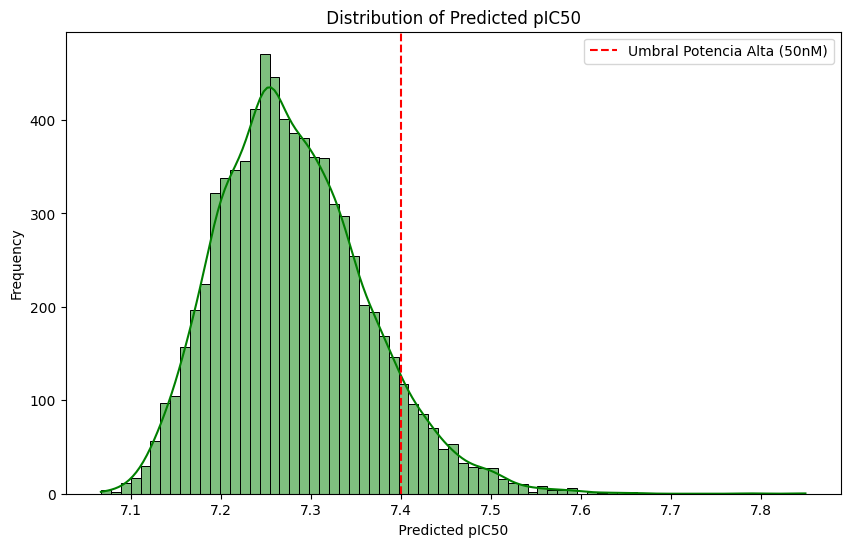

In [96]:

plt.figure(figsize=(10, 6))
sns.histplot(enamine_results['predicted_pIC50'], kde=True, color='green')
plt.axvline(x=7.4, color='red', linestyle='--', label='Umbral Potencia Alta (50nM)')
plt.title(' Distribution of Predicted pIC50 ')
plt.xlabel(' Predicted pIC50 ')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [97]:
enamine_results["predicted_pIC50"] = enamine_results["predicted_pIC50"].astype(float)

In [98]:

best_hits = enamine_results[enamine_results['predicted_pIC50'] > 7.4]

In [99]:
best_hits = best_hits.sort_values(by="predicted_pIC50", ascending=False)

In [100]:
best_hits.drop(columns="Unnamed: 0")

,Unnamed: 0.1,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,...,Bit_1015,Bit_1016,Bit_1017,Bit_1018,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023,predicted_pIC50
4200,27589,CSC=1C=CC=C(C1)NC(=O)C(C)N2CCC(CN3CCCCC3)C2,Z1299743830,361.555,361.547,3.492,-3.172,1,3,35.58,...,0,0,0,0,1,0,0,0,0,7.849245
4420,29198,CC=1C=CC(=CC1C(=O)NC2=CC(=NN2)C=3C=CC=C(F)C3F)...,Z1423689861,391.399,391.394,2.710,-6.048,2,4,91.92,...,0,0,0,0,0,0,0,0,0,7.789506
1136,2883,CSC=1C=CC=C(C1)NC(=O)C=2C=CC=C(C2)N3C=CC=C3,Z94530561,308.406,308.399,4.646,-4.676,1,1,34.03,...,0,0,0,0,0,0,0,0,0,7.661401
782,1589,CCC(C)CS(=O)(=O)NC1CCCNC1,Z2442926991,234.365,234.360,1.712,-1.420,2,3,58.20,...,0,0,0,0,1,0,0,0,0,7.656428
241,307,COC=1C=CC(=CC1)OCCN2CCN(CC2)C(=O)C34CC5CC(CC(C...,Z52144468,398.547,398.539,4.509,-5.029,0,4,42.01,...,0,0,0,0,1,0,0,0,0,7.635757
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3008,14983,C[C@H]1CN(CCOC=2C=CC=C(C2)C(=O)O)CCN1S(C)(=O)=O,Z2483093897,342.417,342.412,0.313,-1.784,1,6,87.15,...,0,0,0,0,1,0,0,0,0,7.400547
5017,33855,CCC1CCCCC1N(C)C(=O)C=2C=CC(OC)=C(C2)N3C=NN=N3,Z1639276622,343.431,343.424,2.869,-4.465,0,5,73.14,...,0,0,0,0,1,0,0,0,0,7.400391
7595,44404,CC1=NN(C)C=2N=CC(=CC12)NC(=O)CC3=CSC(=N3)C4=CC...,Z239537456,364.434,364.426,1.659,-3.220,1,5,85.59,...,0,0,0,0,0,0,0,0,0,7.400313
3470,18581,COC=1C=C(Cl)C=CC1S(=O)(=O)NC2C=CC(C2)C(=O)O,Z1316668281,331.777,331.773,1.864,-2.976,2,5,92.70,...,0,0,0,0,1,0,0,0,0,7.400261


In [101]:
best_hits.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'SMILES', 'Catalog ID', 'MW',
       'MW (desalted)', 'ClogP', 'logS', 'HBD', 'HBA',
       ...
       'Bit_1015', 'Bit_1016', 'Bit_1017', 'Bit_1018', 'Bit_1019', 'Bit_1020',
       'Bit_1021', 'Bit_1022', 'Bit_1023', 'predicted_pIC50'],
      dtype='str', length=1071)

In [102]:
top_20_final = best_hits.head(20).copy()
top_20_final['mol'] = top_20_final['SMILES'].apply(Chem.MolFromSmiles)

Representation of the best 20 molecules:

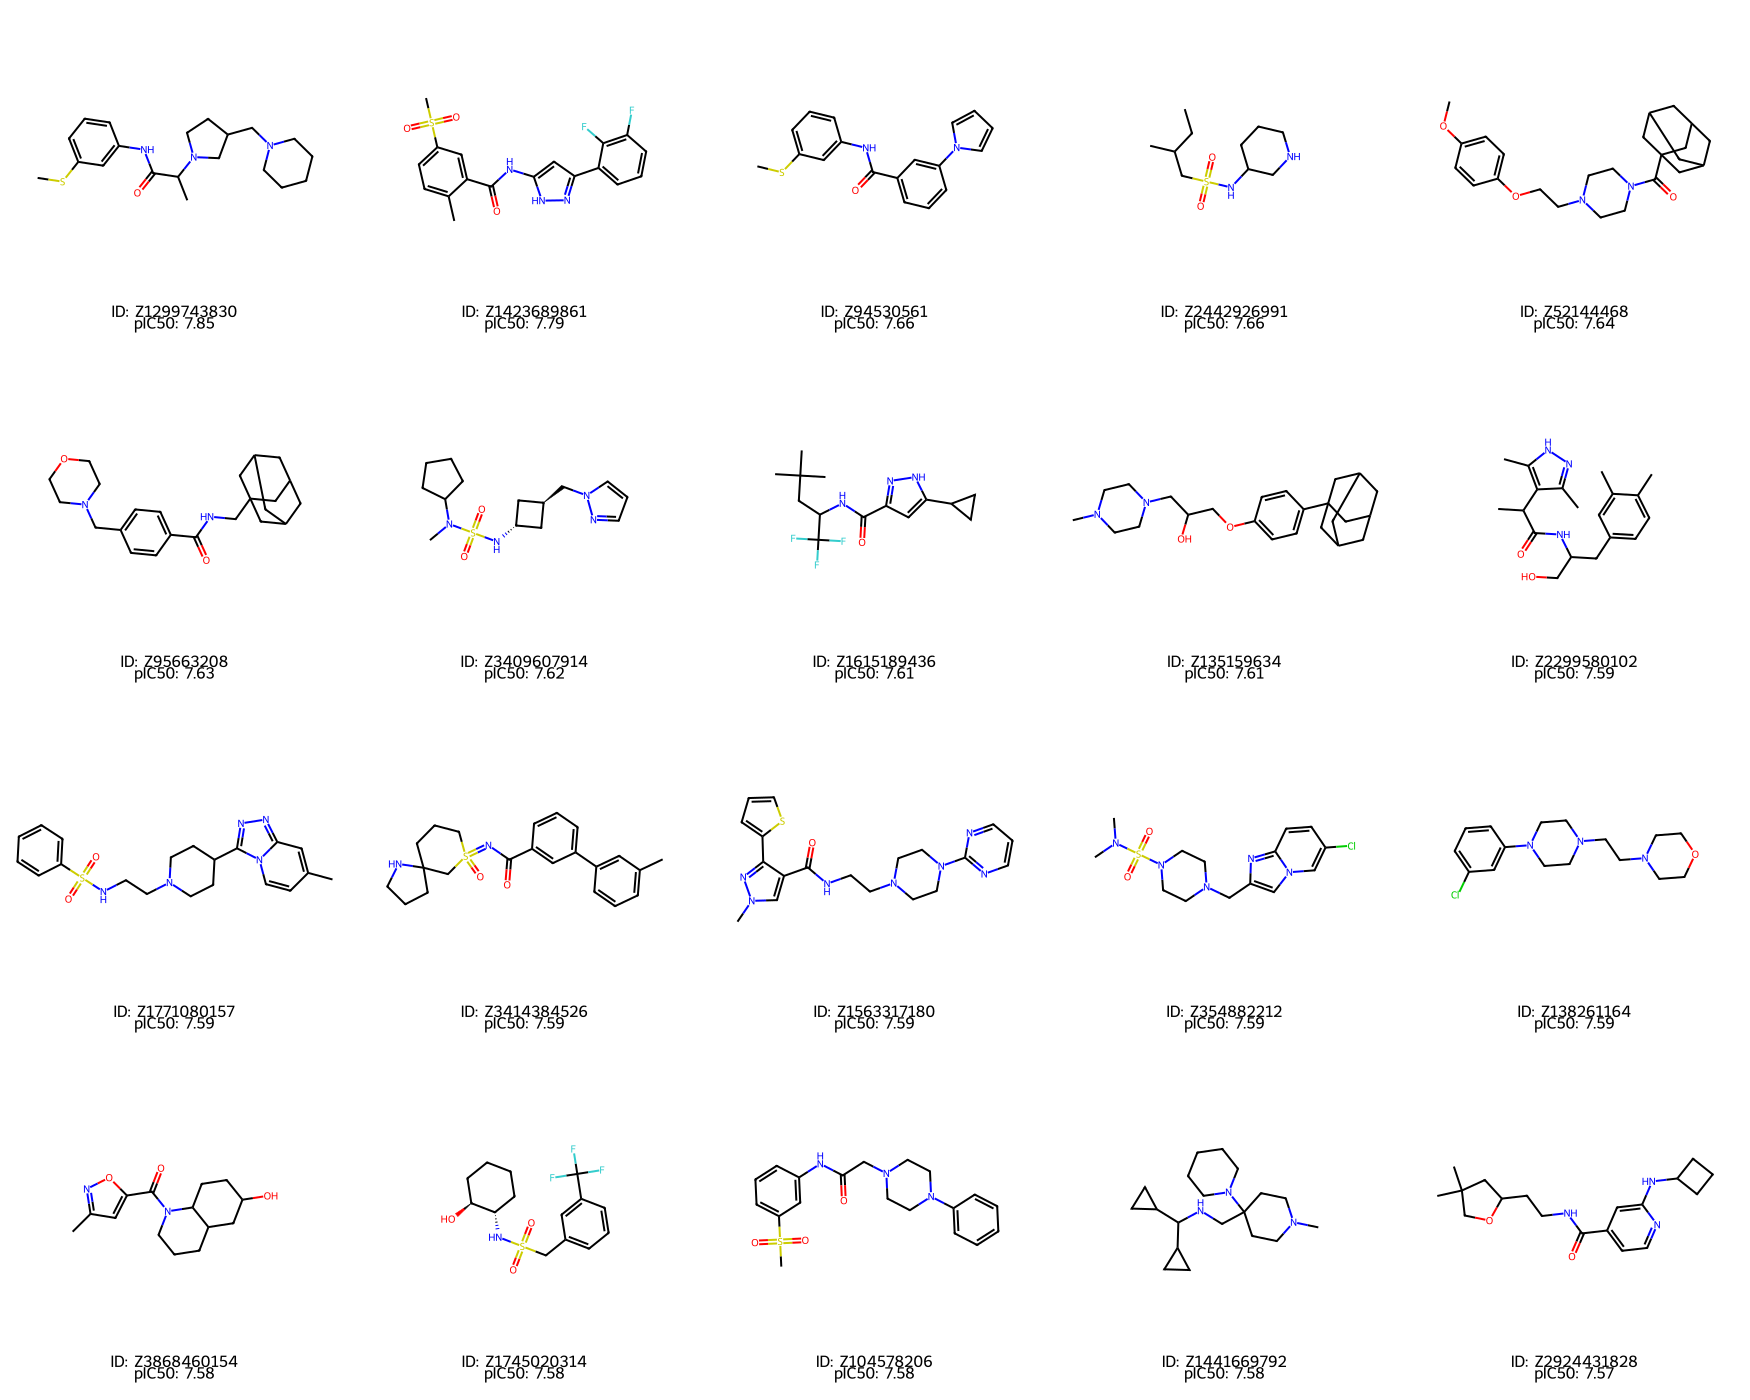

In [103]:

mols_top_20 = top_20_final['mol'].tolist()


legends = [
    f"ID: {row['Catalog ID']}\npIC50: {row['predicted_pIC50']:.2f}"
    for _, row in top_20_final.iterrows()
]

img = Draw.MolsToGridImage(
    mols_top_20,
    molsPerRow=5,
    subImgSize=(350, 350),
    legends=legends,
    useSVG=False
)


img

WE storage this hits:

In [104]:
best_hits.to_csv("../DATA/QSAR_BEST_HITS.csv")

OSError: Cannot save file into a non-existent directory: '../DATA'

##**Model validation by Controls**

In [ ]:

controls_data = {
    'Name': ['Suvorexant', 'Lemborexant'],
    'SMILES': [
        'C[C@@H]1CCN(CCN1C(=O)C2=C(C=CC(=C2)C)N3N=CC=N3)C4=NC5=C(O4)C=CC(=C5)Cl',
        'CC1=NC(=NC=C1OC[C@]2(C[C@H]2C(=O)NC3=NC=C(C=C3)F)C4=CC(=CC=C4)F)C',
    ]
}
df_controls = pd.DataFrame(controls_data)
df_controls['Mol'] = df_controls['SMILES'].apply(Chem.MolFromSmiles)
df=df_controls.copy()

In [ ]:
#Lipophilicity descriptors
df["LogP"] = df["Mol"].apply(Descriptors.MolLogP) #LogP as lypholic behaviour associated with absortion, really important regarding blood-brain barrier absorption


#Charge descriptors
df["MaxAbsPartial"] = df["Mol"].apply(Descriptors.MaxAbsPartialCharge)
df["MaxPartialCharge"] =  df["Mol"].apply(Descriptors.MaxPartialCharge)
df["MinAbsPartial"]= df["Mol"].apply(Descriptors.MinAbsPartialCharge)
df["MinPartialCharge"] =  df["Mol"].apply(Descriptors.MinPartialCharge)

#Size and shape descriptors.
df["TPSA"] = df["Mol"].apply(Descriptors.TPSA) #Topological surface area, defined  polar surface area of a molecule based on its 2D structure, also ensential in blood-brain barrier absorption
df["MW"] = df["Mol"].apply(Descriptors.MolWt) #Molecular weight

df["SlogP_VSA2"] = df["Mol"].apply(lambda x: Descriptors.SlogP_VSA2(x))
df["SMR_VSA1"] = df["Mol"].apply(lambda x: Descriptors.SMR_VSA1(x))

# PBF measures the deviation from planarity; 3D-shaped molecules often show better CNS selectivity.
df["NumAliphaticRings"] = df["Mol"].apply(Lipinski.NumAliphaticRings)

#Aromacitty and rings.
df["AromaticRings"] = df["Mol"].apply(Lipinski.NumAromaticRings) #Really important regarding H1 receptor as the typical drugs usually present two aromatic rings
df["RingCount"] = df["Mol"].apply(Descriptors.RingCount)
df["NumHAcceptors"] = df["Mol"].apply(Chem.Lipinski.NumHAcceptors)
df["NumHDonors"] = df["Mol"].apply(Chem.Lipinski.NumHDonors)
#Flexibility and shape
df["RotatableBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds) #Molecular flexibility, really important considering the induce fit approach Im taking

#Targeted descriptors
df["Kappa1"] = df["Mol"].apply(rdMolDescriptors.CalcKappa1)
df["Kappa2"] = df["Mol"].apply(rdMolDescriptors.CalcKappa2)
df["Fsp3"] = df["Mol"].apply(rdMolDescriptors.CalcFractionCSP3)
df["NumAmideBonds"] = df["Mol"].apply(rdMolDescriptors.CalcNumAmideBonds)
df["HallKierAlpha"] = df["Mol"].apply(rdMolDescriptors.CalcHallKierAlpha)
df["NumAromaticHeterocycles"] = df["Mol"].apply(rdMolDescriptors.CalcNumAromaticHeterocycles)
df["NumChlorine"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[Cl]"))))
df["HeavyAtomCount"] = df["Mol"].apply(Descriptors.HeavyAtomCount)


df["NumFluorine"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[F]"))))
df["NumNitrogen"] = df["Mol"].apply(lambda x: len(x.GetSubstructMatches(Chem.MolFromSmarts("[N]"))))

df["LabuteASA"] = df["Mol"].apply(rdMolDescriptors.CalcLabuteASA)


In [ ]:

def get_3d_descriptors(mol):

    if mol is None:
        return [None] * 6

    try:

        m3d = Chem.AddHs(mol)


        params = AllChem.ETKDGv3()
        params.randomSeed = 42

        if AllChem.EmbedMolecule(m3d, params) == -1:

            if AllChem.EmbedMolecule(m3d, randomSeed=42, useRandomCoords=True) == -1:
                return [None] * 6


        try:
            AllChem.MMFFOptimizeMolecule(m3d)
        except:
            pass


        pbf  = rdMolDescriptors.CalcPBF(m3d)
        npr1 = rdMolDescriptors.CalcNPR1(m3d)
        npr2 = rdMolDescriptors.CalcNPR2(m3d)
        rg   = rdMolDescriptors.CalcRadiusOfGyration(m3d)
        asph = rdMolDescriptors.CalcAsphericity(m3d)
        ecc  = rdMolDescriptors.CalcEccentricity(m3d)

        return [pbf, npr1, npr2, rg, asph, ecc]

    except Exception:
        return [None] * 6


threed_cols = ["PBF", "NPR1", "NPR2", "RadiusOfGyration", "Asphericity", "Eccentricity"]

descriptors_3d_list = df["Mol"].apply(get_3d_descriptors).tolist()


df[threed_cols] = pd.DataFrame(descriptors_3d_list, index=df.index)


df = df.dropna(subset=threed_cols)



In [ ]:

def get_morgan_fp_new(mol):
    if mol is None: return np.zeros(1024)


    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)


    fp = gen.GetFingerprintAsNumPy(mol)
    return fp



fps = np.stack(df["Mol"].apply(get_morgan_fp_new))


df_fps = pd.DataFrame(fps, columns=[f"Bit_{i}" for i in range(1024)], index=df.index)


df = pd.concat([df, df_fps], axis=1)


all_descriptors = descriptors_colums + [f"Bit_{i}" for i in range(1024)]




In [ ]:
df = df.loc[:, ~df.columns.duplicated(keep='first')]

all_descriptors = list(dict.fromkeys(all_descriptors))


model_features = best_model_rf.feature_names_in_


X_control = df[all_descriptors].reindex(columns=model_features)

In [ ]:
X_control_final= X_control.fillna(0)

In [ ]:
df['predicted_pIC50'] = best_model_rf.predict(X_control_final)

enamine_results = df.sort_values(by='predicted_pIC50', ascending=False)

print(enamine_results[['Name', 'predicted_pIC50']].head(10))

          Name  predicted_pIC50
1  Lemborexant         7.494903
0   Suvorexant         7.427452


**As expected the positive control moledcules present good and aceptable predicted pIC50 values**